##  Parisagbp _Mini project2 _ Question1

## Imports

In [1]:
import itertools
from sklearn.neural_network import MLPClassifier, MLPRegressor
from imblearn.under_sampling import RandomUnderSampler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

## Area

In [2]:
#define muculloch pitts
class McCulloch_Pitts_neuron():

  def __init__(self , weights , threshold):
    self.weights = weights    #define weights
    self.threshold = threshold    #define threshold

  def model(self , x):
    #define model with threshold
    if self.weights @ x >= self.threshold:
        return 1
    else:
        return 0

In [4]:
#define model for dataset
def Area(x, y):
    neur1 = McCulloch_Pitts_neuron([-2, -1], -6)  # New weights and threshold
    neur2 = McCulloch_Pitts_neuron([2, -1], 2)  # New weights and threshold
    neur3 = McCulloch_Pitts_neuron([0, 1],   0)  # New weights and threshold

    neur4 = McCulloch_Pitts_neuron([1, 1, 1], 3)  # Threshold unchanged

    z1 = neur1.model(np.array([x, y]))
    z2 = neur2.model(np.array([x, y]))
    z3 = neur3.model(np.array([x, y]))
    z4 = neur4.model(np.array([z1, z2, z3]))

    return list([z4])


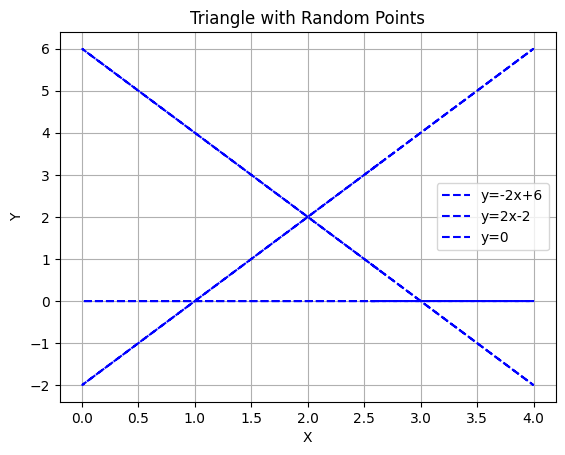

In [15]:
# Plotting lines with legends
# plt.plot(x_values, -2 * x_values + 6, color='blue', linestyle='--', label='y=-2x+6')
# plt.plot(x_values, 2 * x_values -  2, color='blue', linestyle='--', label='y=2x-2')
# plt.plot(x_values, 0 * x_values ,     color='blue', linestyle='--', label='y=0')
# plt.xlabel('X')
# plt.ylabel('Y')
# plt.title('Triangle with Random Points')
# plt.legend()
# plt.grid(True)
# plt.show()

## Labelling and ploting

In [27]:
import numpy as np
import matplotlib.pyplot as plt

# Paste the McCulloch_Pitts_neuron class and the Area function here

# Generate random data points
num_points = 2000
x_values = np.random.uniform(0, 4, num_points)  # Updated x-axis limits
y_values = np.random.uniform(-1, 3, num_points)  # Updated y-axis limits

# Initialize lists to store data points for different z5 values
red_points = []
green_points = []


# Evaluate data points using the Area function
for i in range(num_points):
    z4_value = Area(x_values[i], y_values[i])
    if z4_value == [0]:  # z4 value is 0
        red_points.append((x_values[i], y_values[i],0)) # red points with label 0
    else:  # z4 value is 1
        green_points.append((x_values[i], y_values[i],1)) # green points with label 1



 # Combine inside and outside points
all_points = red_points + green_points

# Convert to DataFrame
df = pd.DataFrame(all_points, columns=['X', 'Y', 'Label'])

# Show the DataFrame
print(df)




             X         Y  Label
0     0.127689  0.575106      0
1     0.027737  2.602532      0
2     2.973200  2.075783      0
3     2.626091  1.235249      0
4     0.551440  2.109828      0
...        ...       ...    ...
1995  1.807227  0.739997      1
1996  2.738497  0.250144      1
1997  2.502153  0.313006      1
1998  2.163317  1.019541      1
1999  2.082287  1.695838      1

[2000 rows x 3 columns]


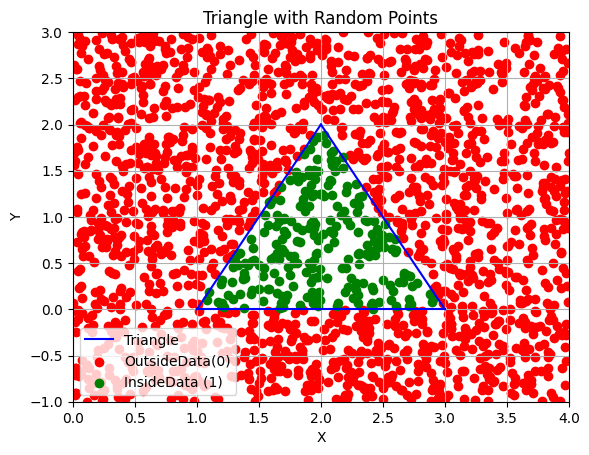

In [43]:
triangle_vertices = [(1, 0), (2, 2), (3, 0)]
# Plot triangle
plt.plot([triangle_vertices[0][0], triangle_vertices[1][0]], [triangle_vertices[0][1], triangle_vertices[1][1]], 'b-')
plt.plot([triangle_vertices[1][0], triangle_vertices[2][0]], [triangle_vertices[1][1], triangle_vertices[2][1]], 'b-')
plt.plot([triangle_vertices[2][0], triangle_vertices[0][0]], [triangle_vertices[2][1], triangle_vertices[0][1]], 'b-',label='Triangle')

# Plot points
red_points = np.array(red_points)
green_points = np.array(green_points)
plt.scatter(red_points[:, 0], red_points[:, 1], c='red', label='OutsideData(0)')
plt.scatter(green_points[:, 0], green_points[:, 1], c='green', label='InsideData (1)')

# Set axis limits
plt.xlim(0, 4)
plt.ylim(-1, 3)

plt.xlabel('X')
plt.ylabel('Y')
plt.title('Triangle with Random Points')
plt.legend()
plt.grid(True)
plt.show()

## MLP

In [39]:
# Define the dataset
X = np.array(df[['X', 'Y']])
y = np.array(df['Label'])

In [40]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=64)

In [41]:
# Define and train the neural network
mlp = MLPClassifier(hidden_layer_sizes=(10,), activation='relu', max_iter=1000, random_state=64)
mlp.fit(X_train, y_train )

/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPClassifier(hidden_layer_sizes=(10,), max_iter=1000, random_state=64)

In [36]:
# Evaluate the model on the test set
accuracy = mlp.score(X_test, y_test)
print(f'Test Accuracy: {accuracy:.4f}')

Test Accuracy: 0.9375


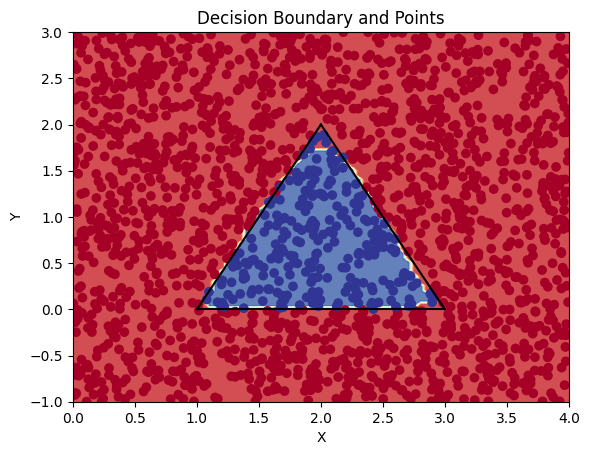

In [45]:
# Plot decision boundary
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.05),
                     np.arange(y_min, y_max, 0.05))
Z = mlp.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot points
# plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, cmap=plt.cm.RdYlBu, alpha=0.8)
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu)

triangle_vertices = [(1, 0), (2, 2), (3, 0)]
# Plot triangle
plt.plot([triangle_vertices[0][0], triangle_vertices[1][0]], [triangle_vertices[0][1], triangle_vertices[1][1]], 'k-')
plt.plot([triangle_vertices[1][0], triangle_vertices[2][0]], [triangle_vertices[1][1], triangle_vertices[2][1]], 'k-')
plt.plot([triangle_vertices[2][0], triangle_vertices[0][0]], [triangle_vertices[2][1], triangle_vertices[0][1]], 'k-',label='Triangle')


plt.xlabel('X')
plt.ylabel('Y')
plt.title('Decision Boundary and Points')
plt.xlim(0, 4)
plt.ylim(-1, 3)
plt.show()
